<a href="https://colab.research.google.com/github/amritpaxt/SkillMap_core_trinity/blob/main/scanning_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
from google.colab import files
uploaded = files.upload()

Saving resume_data_science.pdf to resume_data_science.pdf


In [39]:
!pip install PyPDF2


Resume File: resume_data_science.pdf
TF-IDF Similarity Score: 31.1%
Skill Match Score: 62.5%
🔥 Final Hybrid Match Score: 46.8%

Matched Skills: ['python', 'machine learning', 'pandas', 'numpy', 'data analysis']
Missing Skills: ['sql', 'tensorflow', 'scikit-learn']


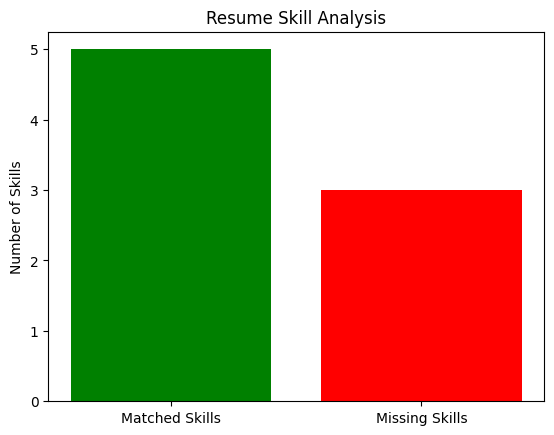

In [40]:

# 3️⃣ Import libraries
import PyPDF2
import re
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# 4️⃣ Extract text from PDF
def extract_text_from_pdf(file_path):
    text = ""
    with open(file_path, "rb") as file:
        reader = PyPDF2.PdfReader(file)
        for page in reader.pages:
            page_text = page.extract_text()
            if page_text:
                text += page_text + " "
    return text

# 5️⃣ Clean and normalize text
def clean_text(text):
    text = text.lower()                       # lowercase
    text = re.sub(r'[^a-z\s]', '', text)      # remove special chars
    text = re.sub(r'\s+', ' ', text).strip()  # remove extra spaces
    return text

# 6️⃣ Job description and required skills
job_description = """
Python Developer
Skills required: Python, Machine Learning, Pandas, NumPy, SQL, Data Analysis, TensorFlow, Scikit-learn
"""

required_skills = ["python","machine learning","pandas","numpy","sql","data analysis","tensorflow","scikit-learn"]

# 7️⃣ Read resume (change file name if needed)
resume_file = list(uploaded.keys())[0]  # picks the uploaded file automatically
resume_text = extract_text_from_pdf(resume_file)

# 8️⃣ Clean text
resume_clean = clean_text(resume_text)
job_clean = clean_text(job_description)

# 9️⃣ TF-IDF similarity
documents = [resume_clean, job_clean]
vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = vectorizer.fit_transform(documents)
tfidf_similarity = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:2])[0][0]

#  🔟 Skill matching
matched_skills = [skill for skill in required_skills if skill in resume_clean]
missing_skills = [skill for skill in required_skills if skill not in resume_clean]
skill_match_percentage = len(matched_skills)/len(required_skills)

# 1️⃣1️⃣ Hybrid score (50% TF-IDF + 50% skill match)
final_score = (tfidf_similarity*0.5 + skill_match_percentage*0.5) * 100

# 1️⃣2️⃣ Print results
print(f"\nResume File: {resume_file}")
print(f"TF-IDF Similarity Score: {round(tfidf_similarity*100,2)}%")
print(f"Skill Match Score: {round(skill_match_percentage*100,2)}%")
print(f"🔥 Final Hybrid Match Score: {round(final_score,2)}%\n")

print("Matched Skills:", matched_skills)
print("Missing Skills:", missing_skills)

# 1️⃣3️⃣ Graph
labels = ["Matched Skills","Missing Skills"]
values = [len(matched_skills), len(missing_skills)]

plt.bar(labels, values, color=['green','red'])
plt.title("Resume Skill Analysis")
plt.ylabel("Number of Skills")
plt.show()